## Import Libraries

We import the necessary libraries for:
- Image processing (OpenCV)
- Feature extraction (HOG)
- Machine learning (scikit-learn)
- Data handling (NumPy)

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Overview

The dataset consists of Pokémon images organized into folders, where each folder represents a class label.
Each class contains approximately 50 images, resulting in a balanced dataset of 18 classes and 900 total images.

In [23]:
RANDOM_STATE = 1996
TEST_SIZE = 0.3
IMAGE_SIZE = (128, 128)
DATASET_DIR = "Pokemon"

class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Number of classes:", len(class_names))
print("Sample classes:", class_names[:10])

Number of classes: 18
Sample classes: ['001 - Bulbasaur', '002 - Ivysaur', '003 - Venusaur', '004 - Charmander', '005 - Charmeleon', '006 - Charizard', '007 - Squirtle', '008 - Wartortle', '009 - Blastoise', '010 - Caterpie']


## Data Distribution

We verify that each class contains a similar number of images to ensure a balanced dataset.

In [24]:
total_images = 0

for class_name in class_names:
    class_path = os.path.join(DATASET_DIR, class_name)
    
    num_images = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    
    total_images += num_images
    print(f"{class_name}: {num_images}")

print("Total images:", total_images)

001 - Bulbasaur: 50
002 - Ivysaur: 50
003 - Venusaur: 50
004 - Charmander: 50
005 - Charmeleon: 50
006 - Charizard: 50
007 - Squirtle: 50
008 - Wartortle: 50
009 - Blastoise: 50
010 - Caterpie: 50
011 - Metapod: 50
012 - Butterfree: 50
013 - Weedle: 50
014 - Kakuna: 50
015 - Beedrill: 50
016 - Pidgey: 50
017 - Pidgeotto: 50
018 - Pidgeot: 50
Total images: 900


## Feature Extraction using HOG

Histogram of Oriented Gradients (HOG) is used to extract edge and texture information from images. This transforms each image into a feature vector.

In [25]:
def extract_hog_features(image):
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    return hog_features

## Load Images and Convert to Features

Each image is:
1. Read from disk
2. Resized to a fixed size (64x64)
3. Converted to grayscale
4. Transformed into HOG features

In [26]:
def load_and_extract_features(directory, image_size=(128, 128)):
    X, y = [], []

    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)

        if not os.path.isdir(label_dir):
            continue

        for filename in os.listdir(label_dir):
            if filename.startswith('.'):
                continue
            if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
                continue

            image_path = os.path.join(label_dir, filename)
            img = cv2.imread(image_path)

            if img is None:
                continue

            img_resized = cv2.resize(img, image_size)
            img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            hog_features = extract_hog_features(img_gray)

            X.append(hog_features)
            y.append(label)

    return np.array(X), np.array(y)


def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


def train_random_forest(train_X, train_y, random_state):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1
    )
    clf.fit(train_X, train_y)
    return clf

## Generate Feature Matrix

We convert all images into feature vectors and corresponding labels.

In [27]:
X, y = load_and_extract_features(DATASET_DIR)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (900, 8100)
Label vector shape: (900,)


### Feature Matrix Overview

The dataset was transformed into a feature matrix using HOG feature extraction.

- Number of samples: 900 images
- Number of features per image: 8100
- Each row represents one image
- Each column represents a HOG-derived feature

- raw image (128x128x3 = 49,152 values)
- Grayscale reduced to 16,384
- HOG reduced to 8100 features

### Image Preprocessing

All images were resized to a fixed dimension of 128 × 128 pixels to ensure consistency across the dataset. Although original images contain three color channels (RGB), they were converted to grayscale to simplify processing and reduce dimensionality. The grayscale images were then transformed into feature vectors using HOG, reducing the input from raw pixel values (128 × 128 × 3 = 49,152) to a more compact and informative representation of 8100 features.

## Train-Test Split

The dataset was divided into training and testing sets using a 70/30 split. Stratified sampling was applied to ensure that each Pokémon class is proportionally represented in both the training and testing datasets.

In [28]:
X_train, X_test, y_train, y_test = split_data(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

## Random Forest Model Training

A Random Forest classifier was trained using the extracted HOG feature vectors.

The model was configured with:
- 100 decision trees (n_estimators = 100)
- A fixed random seed (random_state = 1996) to ensure reproducibility
- Parallel processing (n_jobs = -1) to improve training efficiency

In [29]:
rf_classifier = train_random_forest(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

## Model Evaluation

We evaluate the model using:
- Accuracy
- Classification report (precision, recall, F1-score)
- Confusion matrix

In [30]:
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

print(classification_report(y_test, y_pred))

Accuracy: 32.59%
                  precision    recall  f1-score   support

 001 - Bulbasaur       0.23      0.40      0.29        15
   002 - Ivysaur       0.39      0.60      0.47        15
  003 - Venusaur       0.56      0.67      0.61        15
004 - Charmander       0.60      0.40      0.48        15
005 - Charmeleon       0.20      0.13      0.16        15
 006 - Charizard       0.24      0.27      0.25        15
  007 - Squirtle       0.15      0.13      0.14        15
 008 - Wartortle       0.20      0.20      0.20        15
 009 - Blastoise       0.25      0.27      0.26        15
  010 - Caterpie       0.31      0.27      0.29        15
   011 - Metapod       0.33      0.53      0.41        15
012 - Butterfree       0.23      0.40      0.29        15
    013 - Weedle       0.27      0.20      0.23        15
    014 - Kakuna       0.56      0.67      0.61        15
  015 - Beedrill       0.45      0.33      0.38        15
    016 - Pidgey       0.29      0.13      0.18       

### Results and Evaluation

#### Results:
- Accuracy: 32.59%
18 classes → random baseline ≈ 5.5% meaning the model is approx 6x better than random guessing

Stronger classes (easier to recognize)
- Venusaur → 0.61 F1
- Kakuna → 0.61 F1
- Metapod → 0.41 F1

Weaker classes (harder to recognize)
- Pidgeotto → 0.10 F1
- Squirtle → 0.14 F1
- Charmeleon → 0.16 F1

#### Summary

The Random Forest baseline model achieved an accuracy of **32.59%** on the test set across 18 Pokémon classes.

Given that random guessing would yield approximately 5.5% accuracy (1/18 classes), the model demonstrates a significant improvement and confirms that HOG features capture meaningful visual patterns.

Performance varied across classes. Some Pokémon such as *Venusaur* and *Kakuna* achieved higher F1-scores (0.61), indicating that the model was able to effectively distinguish their visual features. In contrast, classes such as *Pidgeotto* and *Squirtle* showed lower performance, suggesting difficulty in differentiating between visually similar Pokémon.

Overall, while the Random Forest model provides a reasonable baseline, its performance is limited by the use of handcrafted features and its inability to capture complex spatial patterns in image data.

This baseline establishes a reference point for comparison with more advanced models, such as Convolutional Neural Networks, which are expected to achieve higher accuracy by learning hierarchical image features directly from raw pixel data.

## Confusion Matrix

The confusion matrix provides a detailed view of model performance by showing how predictions are distributed across all classes.

It highlights which Pokémon are commonly misclassified, offering insight into patterns of confusion between visually similar classes.

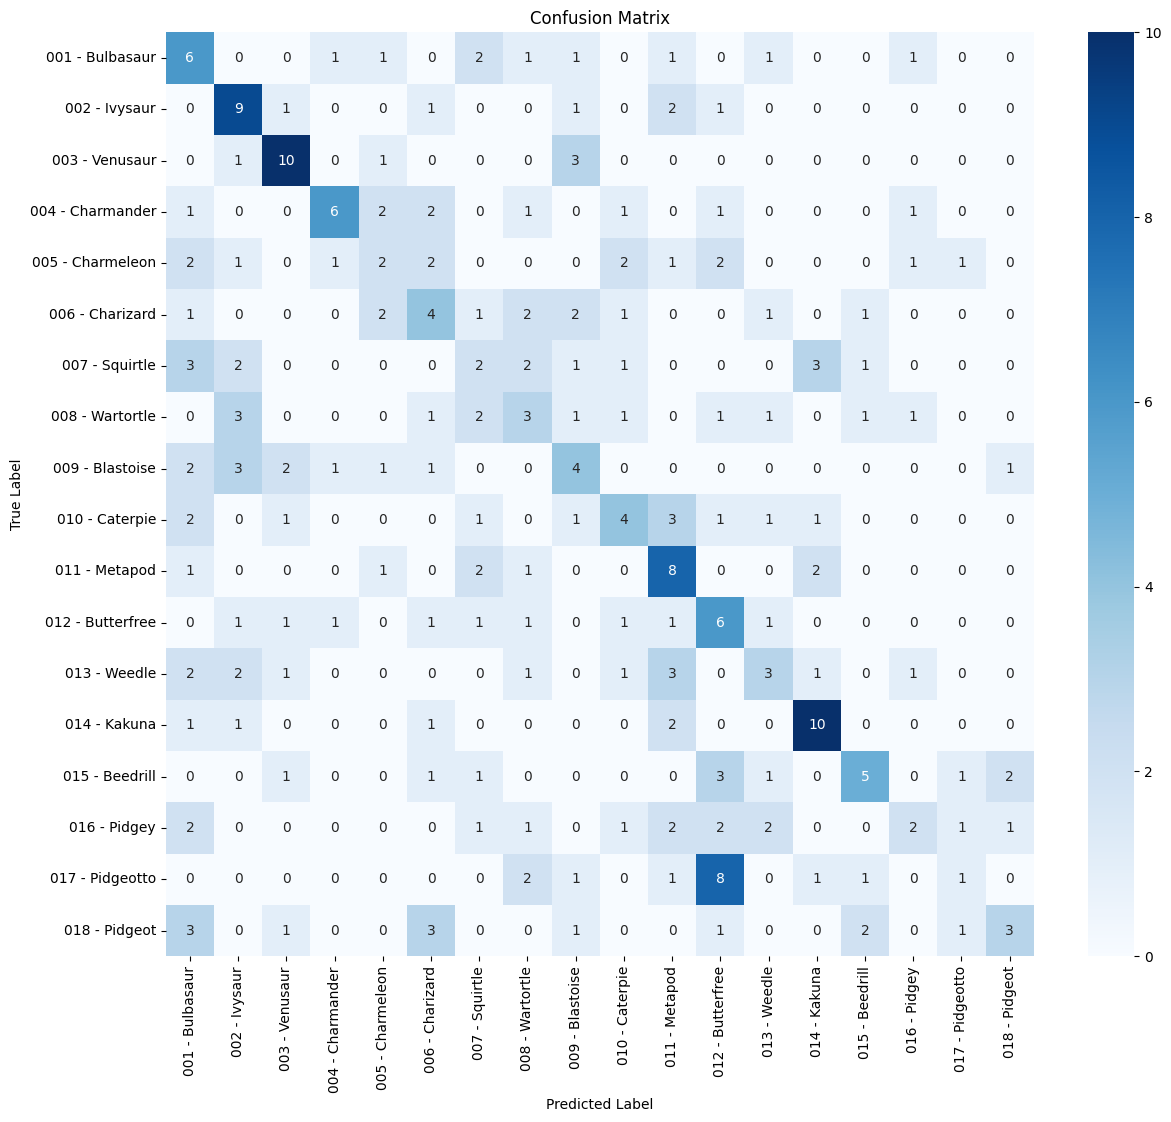

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

### Results:
Strong Class Performance
- Venusaur → 10 correct
- Kakuna → 10 correct
- Ivysaur → 9 correct
- Metapod → 8 correct

Major Confusion Areas
Evolution Confusion
- Charmander → Charmeleon → Charizard
- Model struggles with fine-grained differences within evolution chains

Pidgey Line Confusion
- Pidgey / Pidgeotto / Pidgeot heavily mixed
- Very low diagonal 

Squirtle Line Confusion
- Squirtle / Wartortle / Blastoise also mixed
-  weaker separation

Overall the model is good at distinct Pokémon and struggles with similar-looking Pokémon

### Confusion Matrix Analysis

The confusion matrix reveals important patterns in model performance across Pokémon classes.

The model performs well on visually distinct Pokémon such as *Venusaur*, *Ivysaur*, and *Kakuna*, which show strong diagonal values, indicating correct classifications.

However, significant confusion is observed among Pokémon within the same evolutionary lines. For example, *Charmander*, *Charmeleon*, and *Charizard* are frequently misclassified as one another. A similar pattern is observed for *Pidgey*, *Pidgeotto*, and *Pidgeot*, as well as the *Squirtle* evolution line.

These patterns suggest that while HOG features capture general shape and edge information, they are insufficient for distinguishing subtle visual differences between closely related classes.

This limitation highlights the need for more advanced models, such as Convolutional Neural Networks, which can learn hierarchical and fine-grained visual features directly from raw image data.